1. Fill in the code in the fields marked `# YOUR SOLUTION`.
2. Run the `PUBLIC TEST` to check your results. If the test fields do not show any errors (AssertionError), you have met the technical requirements.
3. For the explanation (Text), students must type directly into the designated Markdown fields.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Set random seed
np.random.seed(42)

#### **QUESTION 1: DATA PREPROCESSING (30 points)**

**1a. Data Cleaning (10 pts):**
- Read the data file `Diabetes.csv` into the variable `df`.
- Delete the columns `'ID'` and `'No_Pation'`.
- The `'CLASS'` column has some missing values ​​(NaN). Fill these missing values ​​with the string `'P'`.
- The `'HbA1c'` and `'VLDL'` columns have missing values. Fill them with the median value of the columns.

In [4]:
# YOUR SOLUTION
df = pd.read_csv("Diabetes.csv")

In [5]:
df.drop(['ID', 'No_Pation'], axis=1, inplace=True, errors='ignore')

In [6]:
df['CLASS'] = df['CLASS'].str.strip()
df['CLASS'] = df['CLASS'].fillna('P')

In [7]:

df['HbA1c'] = df['HbA1c'].fillna(df['HbA1c'].median())
df['VLDL'] = df['VLDL'].fillna(df['VLDL'].median())

In [8]:
# PUBLIC TEST
assert 'ID' not in df.columns
assert df['CLASS'].isnull().sum() == 0
assert df['HbA1c'].isnull().sum() == 0
assert df['VLDL'].isnull().sum() == 0
print("Pass 1a!")

Pass 1a!


**1b. Correlations (10 pts):**
- Identifying highly correlated numeric columns (threashold is 0.6)
- Choose and drop some columns in highly correlated pairs.

In [9]:
# YOUR SOLUTION
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.6
high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Columns to be dropped due to high correlation (> {threshold}): {high_corr_cols}")

Columns to be dropped due to high correlation (> 0.6): ['Cr']


In [11]:
# YOUR SOLUTION
df.drop(columns=high_corr_cols, inplace=True)

print("\nRemaining columns after dropping high correlation pairs:")
print(df.columns.tolist())


Remaining columns after dropping high correlation pairs:
['Gender', 'AGE', 'Urea', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


In [12]:
# PUBLIC TEST
assert round(corr_matrix.loc['AGE', 'BMI'], 2) == 0.38
assert df.shape[1] == 11
print("Pass 1b!")

Pass 1b!


In [14]:
df['HbA1c'].tolist()

[8.0,
 4.9,
 4.9,
 4.9,
 4.9,
 4.0,
 4.0,
 4.0,
 4.0,
 4.0,
 4.2,
 4.0,
 4.1,
 5.1,
 4.0,
 5.0,
 5.4,
 4.1,
 4.1,
 4.0,
 5.1,
 4.5,
 5.0,
 5.3,
 5.0,
 4.1,
 5.5,
 4.0,
 5.4,
 4.0,
 5.4,
 4.3,
 5.0,
 4.5,
 5.1,
 4.0,
 5.1,
 5.4,
 5.0,
 4.0,
 4.8,
 5.5,
 5.4,
 4.3,
 5.0,
 4.7,
 3.7,
 5.0,
 5.5,
 5.0,
 4.0,
 4.0,
 5.0,
 5.4,
 5.0,
 4.5,
 5.0,
 4.5,
 5.0,
 4.1,
 5.0,
 4.2,
 4.3,
 4.9,
 5.4,
 4.0,
 5.0,
 4.9,
 5.4,
 5.4,
 5.6,
 4.3,
 4.0,
 4.3,
 4.2,
 4.1,
 5.0,
 4.0,
 5.4,
 5.0,
 0.9,
 4.0,
 5.3,
 4.3,
 4.2,
 4.0,
 4.0,
 4.5,
 4.9,
 5.4,
 5.6,
 5.4,
 0.9,
 5.4,
 4.3,
 5.4,
 5.6,
 4.9,
 0.9,
 5.4,
 4.1,
 0.9,
 5.4,
 6.0,
 6.0,
 6.0,
 5.7,
 5.7,
 5.7,
 5.8,
 6.2,
 6.1,
 6.2,
 6.1,
 6.0,
 6.0,
 6.2,
 6.0,
 5.8,
 6.1,
 6.0,
 6.4,
 6.1,
 6.4,
 6.0,
 6.4,
 6.2,
 5.8,
 5.9,
 6.0,
 6.0,
 6.0,
 5.9,
 5.8,
 5.9,
 6.0,
 6.1,
 6.0,
 6.0,
 5.9,
 5.8,
 6.1,
 6.0,
 6.0,
 6.1,
 6.0,
 5.9,
 5.7,
 5.8,
 5.9,
 6.3,
 6.0,
 5.7,
 5.8,
 6.4,
 6.3,
 12.3,
 6.7,
 10.2,
 10.2,
 11.2,
 6.5,
 11.2,
 6.9,
 6.9,
 7.7,

**1c. Explanation (10 points):** 

Why, in the case of column `HbA1c`, did you use the median value to fill in the missing data instead of the mean value?

# Explanation
Using the median is preferred over the mean for medical data like HbA1c for these reasons:

Robustness to Outliers: Medical datasets often contain extreme values (e.g., patients with very high blood sugar). The mean is heavily influenced by these outliers, while the median remains stable and represents the "typical" patient better.

Handling Skewed Data: Clinical measurements rarely follow a perfect "normal distribution." If the data is skewed, the mean gets pulled toward the tail, whereas the median stays at the center of the distribution.

In short: The median is a safer, more reliable estimate of the central tendency when dealing with real-world, non-symmetrical clinical data.

#### **QUESTION 2: MODEL TRAINING (40 Points)**

**2a. Feature Engineering (15 pts):**
- Use `LabelEncoder` to encode the `'Gender'` column.
- Map the `'CLASS'` column to numbers: `{'N': 0, 'P': 1, 'Y': 2}`.
- Separate `df` into `X` (feature) and `y` (CLASS label).
- Use `StandardScaler` to normalize `X` and store it in the `X_scaled` variable.

In [ ]:
# YOUR SOLUTION
from sklearn.preprocessing import LabelEncoder
    
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])



In [44]:
mapping = {'N': 0, 'P': 1, 'Y': 2}
df['CLASS'] = df['CLASS'].map(mapping)

In [36]:
X = df.drop('CLASS', axis=1)
y = df['CLASS']

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
# PUBLIC TEST
assert df['Gender'].dtype in ['int32', 'int64']
assert df['CLASS'].dtype in ['int32', 'int64', 'float64']
assert 'X' in locals() and 'y' in locals()
assert 'X_scaled' in locals()
assert X_scaled.shape[1] == df.shape[1] - 1
print("Pass 2a!")

Pass 2a!


**2b. Modeling (15 points):**
- Divide `X_scaled` and `y` into a training set and a test set with a ratio of 80-20. The parameter `random_state=42` is required and is stored in the variables `X_train, X_test, y_train, y_test`.
- Initialize and train the `KNeighborsClassifier` model with the parameter `n_neighbors=5`. Store the model in the variable `knn`.
- Use the model to make predictions on the `X_test` set, then calculate the accuracy and store the results in the variable `acc_score`.

In [46]:
# YOUR SOLUTION
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [126]:
n_neighbors = 5
knn = KNeighborsClassifier(n_neighbors)

In [137]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_score=accuracy_score(y_test, y_pred)

In [138]:
# PUBLIC TEST
assert 'X_train' in locals() and 'X_test' in locals()
assert X_train.shape[0] == int(len(df) * 0.8)
assert 'knn' in locals()
assert knn.n_neighbors == 5
assert 'acc_score' in locals() and isinstance(acc_score, float)
assert acc_score == 0.935
print("Pass 2b!")

Pass 2b!


**2c. Conceptual Understanding (10 points):** 

Briefly explain why using `StandardScaler` (data normalization) is mandatory before incorporating data into the KNN model?

*Your Solution:*
# DẠ THƯA CÔ 
Using StandardScaler is crucial for the KNN model because of how it calculates "closeness" between data points.

Distance-Based Algorithm: KNN works by calculating the Euclidean distance between points. This formula sums the squared differences of all features. If one feature has a much larger range (e.g., "Salary" in thousands) than another (e.g., "Age" in tens), the feature with the larger scale will dominate the distance calculation, making the smaller-scale feature irrelevant.

Equal Contribution: Normalization transforms all features to a common scale (usually a mean of 0 and a standard deviation of 1). This ensures that every feature contributes equally to the distance calculation, preventing features with larger numerical magnitudes from biasing the model's predictions.

In short: Without scaling, the model becomes biased toward features with larger numerical ranges rather than the features that are actually more predictive.


#### **QUESTION 3: RESULTS INTERPRETATION (30 Points)**

**3a. Confusion Matrix (20 pts):**
- Calculate the Confusion Matrix based on `y_test` and `y_pred` from question 2, and store it in the variable `cm`.
- Use the `seaborn.heatmap` library to plot a visualization of `cm`.

In [139]:
# YOUR SOLUTION
cm = confusion_matrix(y_test, y_pred)

<Axes: >

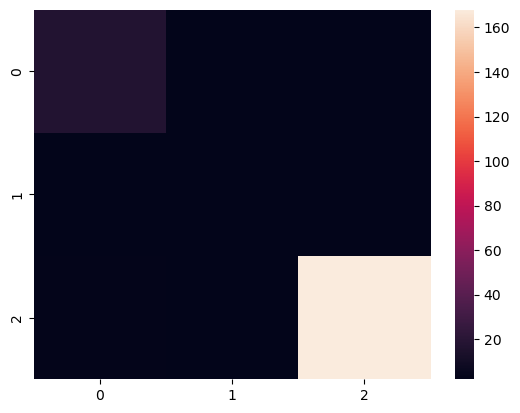

In [142]:
sns.heatmap(cm)

In [140]:
# PUBLIC TEST
assert type(cm) == np.ndarray
assert cm.shape == (3, 3)
assert cm[0][0] == 17 and cm[2][2] == 168
print("Pass 3a!")

Pass 3a!


**3b. Explanation (10 points):** 

Observe the Confusion Matrix you just drew. In the medical context of diabetes diagnosis, what practical consequences would occur if the model incorrectly predicted a person as "Currently suffering from the disease" (Type 2) instead of "Not suffering from the disease" (Type 0)?

*Your Solution:*
# EM CŨNG HONG BIC LUONN CÔ ƠIIIIIII
In the context of diabetes diagnosis, predicting a healthy person as having the disease is a False Positive. The consequences are:

Psychological Distress: The patient suffers unnecessary anxiety and fear.

Financial & Resource Waste: Costs incurred from further, unneeded diagnostic tests and hospital visits.

Harmful Interventions: If treatment is started, the patient faces unnecessary side effects (e.g., hypoglycemia from insulin), which can be dangerous.

Erosion of Trust: Incorrect results weaken the patient's confidence in the healthcare system.

While this is less life-threatening than a False Negative (missing an actual case), it remains a serious clinical error that risks patient safety and wastes healthcare resources.

# Data Mining & Machine Learning: Essential Exam Q&A

## 1. Data Preprocessing
| Question | Answer |
| :--- | :--- |
| **Why use median instead of mean to fill missing values?** | The median is **robust to outliers**. Clinical data often contains extreme values that skew the mean, whereas the median remains a stable estimate of the "typical" patient value. |
| **Why is `StandardScaler` mandatory for KNN?** | KNN relies on **Euclidean distance**. If features have different scales, large-range features will dominate the calculation. Scaling ensures all features contribute equally. |
| **What is the purpose of `LabelEncoder`?** | It converts categorical data (strings/labels) into **numerical values**, as machine learning algorithms can only process numerical input. |
| **How to handle highly correlated columns?** | We identify them using `df.corr()` and drop one of the columns in a highly correlated pair (threshold > 0.6) to reduce redundancy and prevent collinearity issues. |

## 2. Modeling & Evaluation
| Question | Answer |
| :--- | :--- |
| **Why split data into Train and Test sets?** | To evaluate **generalization**. Training on all data leads to *overfitting* (memorizing), while the test set measures performance on *unseen* data. |
| **What is Overfitting vs. Underfitting?** | **Overfitting:** The model learns noise/details of training data, performing poorly on test data. **Underfitting:** The model is too simple to capture the underlying pattern of the data. |
| **What is the role of `random_state`?** | It ensures **reproducibility**. It guarantees that the data split and model initialization are identical every time you run the code. |
| **How to choose the best `n_neighbors` (k)?** | A small $k$ is sensitive to noise (**overfitting**), while a large $k$ can ignore local patterns (**underfitting**). We usually find the optimal $k$ through experimentation. |

## 3. Clinical Context & Interpretation
| Question | Answer |
| :--- | :--- |
| **What is a False Positive in a medical context?** | Predicting a healthy person as having a disease. It leads to **unnecessary patient anxiety, wasted diagnostic resources, and potential harm** from unneeded treatments. |
| **What is a False Negative in a medical context?** | Predicting a sick person as healthy. It is generally more dangerous as it **delays life-saving treatment**. |
| **How to interpret a Confusion Matrix?** | It shows the count of **True Positives, True Negatives, False Positives, and False Negatives**, allowing us to see exactly where the model is making errors. |